# National Parks and National Change

## Group Name: The Correlators
### Group Members:
- Anvi Mehta
- Jamal Moussa 
- Katie Bakkonnen
- Mia George



# Introduction

Hiking is more than just a pastime for many; it's an experience that connects us with nature, offering both physical and mental rejuvenation. With this in mind, we aim to address the following key question:

How do periods of societal change and disturbance influence patterns of visitation in national parks, including but not limited to political elections, public health crises, and economic downturns?

Understanding how major events affect park visitation provides insights into human behavior under conditions of stress and uncertainty. This research seeks to identify correlations between unforeseen major events and park usage to help us gain a broader understanding of the interplay between society and the environment.

In [2]:
# Imports
import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
import plotly.express as px
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import seaborn as sns

sns.set_style('whitegrid')

# Datasets

We are using the following datasets to explore our question. Two of these datasets are from the government (National Park Service and National Archives) and one is from the MIT Election Data + Science Lab.

National Park Dataset

This dataset has the visitation data for all of the National Parks in the US. We will focus on the parks that are in the Continental United States. Each field was reported as a monthly total for each month of every year from 1979 to present. There is also annual data from 1904-1979. This dataset has around 35,000 samples. Something interesting that we observed from the data is the difference in visitors between 2019 and 2020. For example, in Yosemite, which is in a blue state, from August 2019 to August 2020 visitation dropped by 47%. In Arches, which is in a red state, from August 2019 to August 2020 visitation dropped by only 11%. We thought that it would be interesting to explore these trends in all of the states.

Electoral College Dataset, Presidential Candidate Dataset

The first link above has the electoral college results for every election starting from 1789. The tables have the state, presidential and vice-president candidate and how many electoral votes they each got. The second link contains the party of every presidential candidate. We selected these two datasets because we wanted to use the electoral college data by state to see if national park visitation was affected based on political leanings, but a lot of cleaning is needed for it to be usable since we only want the state, electoral college votes, presidential candidate, and their party.


# EDA & Preprocessing


### Load data

In [3]:
# Load data
df = pd.read_csv('Datasets/national_parks.csv')

# Clean numeric columns
numeric_columns = ['RecreationVisits', 'NonRecreationVisits']
for col in numeric_columns:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(',', ''), errors='coerce')

df['RecreationVisits'] = df['RecreationVisits'].fillna(0)
df['NonRecreationVisits'] = df['NonRecreationVisits'].fillna(0)
df['TotalVisits'] = df['RecreationVisits'] + df['NonRecreationVisits']

print(f"Data loaded: {len(df)} records")
print(f"Parks: {df['ParkName'].nunique()}")
print(f"Years: {df['Year'].min()} - {df['Year'].max()}")


Data loaded: 34151 records
Parks: 63
Years: 1979 - 2024


/var/folders/y1/sdp6z2n512jfxp76fkhspjfc0000gn/T/ipykernel_29958/3613798514.py:2: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Datasets/national_parks.csv')


### Great Smoky Mountains National Park Visitation Example

After loading the monthly and yearly datasets into a dataframe we first looked at the visitation over time for each park on a line graph for the monthly and yearly data. For the sake of this report we will only display the Great Smoky Mountains national park. We found that the monthly dataset provided a solid understanding of the seasonality of the park while the yearly datasets allowed us to see the overall visitation trend of the parks. This led us to explore the seasonality and overall trend of visitation throughout the report.

/var/folders/y1/sdp6z2n512jfxp76fkhspjfc0000gn/T/ipykernel_29958/3555911254.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  smoky_mountains['Date'] = pd.to_datetime(smoky_mountains['Year'].astype(str) + '-' + smoky_mountains['Month'].astype(str).str.zfill(2))


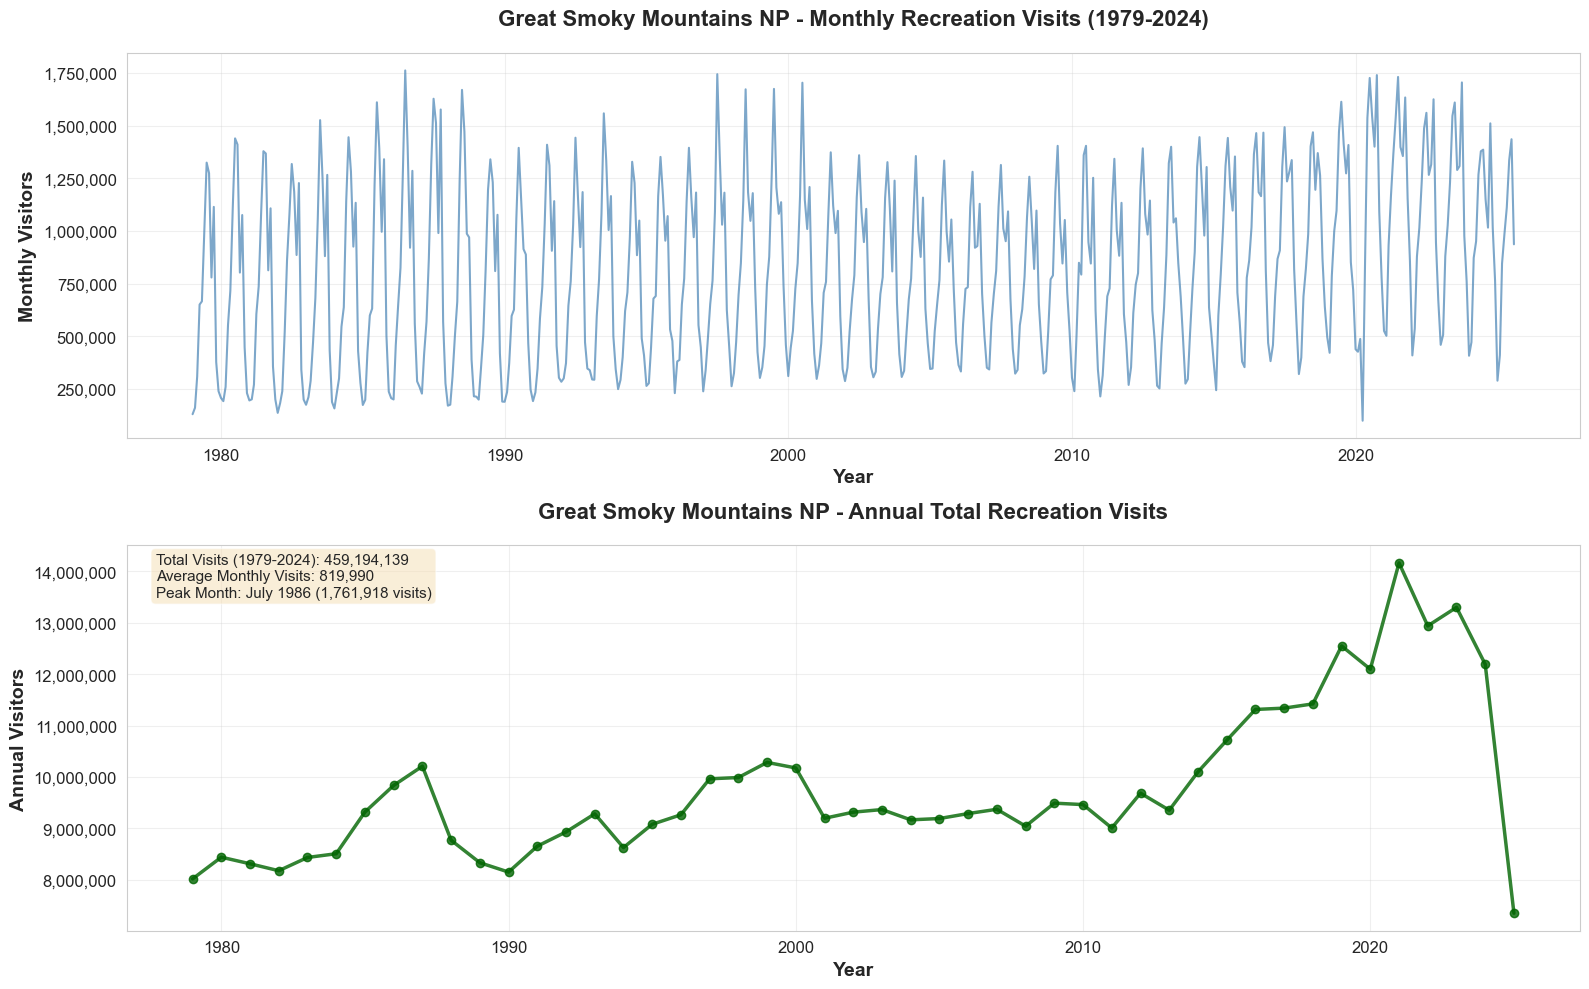


Great Smoky Mountains National Park Summary:
Data Range: 1979 - 2025
Total Recreation Visits: 459,194,139.0
Average Monthly Visits: 819,990
Highest Monthly Visits: 1,761,918 (July 1986)
Lowest Monthly Visits: 99,371


In [ ]:
# Load the cleaned national parks data
df_clean = pd.read_csv('Datasets/national_parks_cleaned.csv')

# Filter for Great Smoky Mountains NP
smoky_mountains = df_clean[df_clean['ParkName'] == 'Great Smoky Mountains NP'].copy()

# Create date column for better plotting
smoky_mountains['Date'] = pd.to_datetime(smoky_mountains['Year'].astype(str) + '-' + smoky_mountains['Month'].astype(str).str.zfill(2))
smoky_mountains = smoky_mountains.sort_values('Date')

# Create figure with subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Monthly visitation over time
ax1.plot(smoky_mountains['Date'], smoky_mountains['RecreationVisits'], 
         linewidth=1.5, color='steelblue', alpha=0.7)
ax1.set_title('Great Smoky Mountains NP - Monthly Recreation Visits (1979-2024)', 
              fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Year', fontsize=14, fontweight='bold')
ax1.set_ylabel('Monthly Visitors', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)
ax1.tick_params(labelsize=12)

# Format y-axis with commas
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Plot 2: Yearly total visitation
yearly_smoky = smoky_mountains.groupby('Year')['RecreationVisits'].sum().reset_index()
ax2.plot(yearly_smoky['Year'], yearly_smoky['RecreationVisits'], 
         linewidth=2.5, color='darkgreen', marker='o', markersize=6, alpha=0.8)
ax2.set_title('Great Smoky Mountains NP - Annual Total Recreation Visits', 
              fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Year', fontsize=14, fontweight='bold')
ax2.set_ylabel('Annual Visitors', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.tick_params(labelsize=12)

# Format y-axis with commas
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# Add summary statistics as text
total_visits = smoky_mountains['RecreationVisits'].sum()
avg_monthly = smoky_mountains['RecreationVisits'].mean()
max_month = smoky_mountains.loc[smoky_mountains['RecreationVisits'].idxmax()]

summary_text = (
    f"Total Visits (1979-2024): {total_visits:,.0f}\n"
    f"Average Monthly Visits: {avg_monthly:,.0f}\n"
    f"Peak Month: {max_month['Date'].strftime('%B %Y')} ({max_month['RecreationVisits']:,.0f} visits)"
)

ax2.text(0.02, 0.98, summary_text, transform=ax2.transAxes, 
         fontsize=11, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print(f"\nGreat Smoky Mountains National Park Summary:")
print(f"{'='*60}")
print(f"Data Range: {smoky_mountains['Year'].min()} - {smoky_mountains['Year'].max()}")
print(f"Total Recreation Visits: {total_visits:,}")
print(f"Average Monthly Visits: {avg_monthly:,.0f}")
print(f"Highest Monthly Visits: {max_month['RecreationVisits']:,.0f} ({max_month['Date'].strftime('%B %Y')})")
print(f"Lowest Monthly Visits: {smoky_mountains['RecreationVisits'].min():,.0f}")
print(f"{'='*60}")


### Cluster Parks By Size

We wanted to determine the different sizes in parks. We found that we can divide the parks into 4 different sizes, small, medium, large and extra large. The most notable parks were Gates of the Arctic National Park & Preserve in Alaska being the smallest with around 12,000 visitors in 2024 and Great Smoky Mountains National Park being the most visited in 2024 with over 12 million visitors.

In [ ]:
# Calculate total visitation per park
park_totals = df.groupby('ParkName')['TotalVisits'].sum().reset_index()
park_totals.columns = ['ParkName', 'TotalVisitsAllTime']

# Cluster into 4 size categories using quantiles
park_totals['SizeCategory'] = pd.qcut(park_totals['TotalVisitsAllTime'], 
                                        q=4, 
                                        labels=['Small', 'Medium', 'Large', 'Extra Large'])

# Merge back to main dataframe
df = df.merge(park_totals[['ParkName', 'SizeCategory']], on='ParkName', how='left')

print("Park distribution by size:")
print(park_totals['SizeCategory'].value_counts())
print(f"\nExtra Large parks: {park_totals[park_totals['SizeCategory']=='Extra Large']['TotalVisitsAllTime'].min():,.0f} - {park_totals[park_totals['SizeCategory']=='Extra Large']['TotalVisitsAllTime'].max():,.0f}")
print(f"Large parks: {park_totals[park_totals['SizeCategory']=='Large']['TotalVisitsAllTime'].min():,.0f} - {park_totals[park_totals['SizeCategory']=='Large']['TotalVisitsAllTime'].max():,.0f}")
print(f"Medium parks: {park_totals[park_totals['SizeCategory']=='Medium']['TotalVisitsAllTime'].min():,.0f} - {park_totals[park_totals['SizeCategory']=='Medium']['TotalVisitsAllTime'].max():,.0f}")
print(f"Small parks: {park_totals[park_totals['SizeCategory']=='Small']['TotalVisitsAllTime'].min():,.0f} - {park_totals[park_totals['SizeCategory']=='Small']['TotalVisitsAllTime'].max():,.0f}")


### Calculating Average Monthly Visitation by Park

In [ ]:
# Calculate average visitation by park and month across all years
# Include ParkType so we can filter by it later
monthly_avg = df.groupby(['ParkName', 'ParkType', 'SizeCategory', 'Month'])['TotalVisits'].mean().reset_index()
monthly_avg.columns = ['ParkName', 'ParkType', 'SizeCategory', 'Month', 'AvgVisits']

print(f"Monthly averages calculated for {monthly_avg['ParkName'].nunique()} parks")
print(f"Park types: {monthly_avg['ParkType'].unique()}")
monthly_avg.head(12)

### Graphing Monthly Visitation by Park Size
We then calculated the average visitation of each park to gain a better understanding of visitation trends for each park per month. We noticed that on average, most parks have the highest visitation rates in the summer. This led us to explore what the seasonality of visitation is for each park.

In [ ]:
# Create 4 separate line graphs (one for each size category)
# Filter to show ONLY National Parks (ParkType == 'National Park')
size_categories = ['Extra Large', 'Large', 'Medium', 'Small']
colors = plt.cm.tab20(np.linspace(0, 1, 20))

for size in size_categories:
    # Filter data for this size category - ONLY National Parks
    size_data = monthly_avg[
        (monthly_avg['SizeCategory'] == size) & 
        (monthly_avg['ParkType'] == 'National Park')
    ].copy()
    
    # Get unique parks for THIS size category only
    parks = sorted(size_data['ParkName'].unique())
    
    # Skip if no parks in this category
    if len(parks) == 0:
        print(f"No National Parks in {size} category, skipping...\n")
        continue
    
    # Create individual figure for each size category
    fig, ax = plt.subplots(figsize=(18, 14))
    
    # Plot ONLY the parks in this specific size category
    for i, park in enumerate(parks):
        park_data = size_data[size_data['ParkName'] == park].sort_values('Month')
        if len(park_data) > 0:  # Only plot if data exists
            ax.plot(park_data['Month'], park_data['AvgVisits'], 
                    marker='o', linewidth=2, markersize=4, 
                    label=park, alpha=0.7, color=colors[i % len(colors)])
    
    # Customize the plot
    ax.set_xlabel('Month', fontsize=16, fontweight='bold')
    ax.set_ylabel('Average Visitation', fontsize=16, fontweight='bold')
    ax.set_title(f'{size} National Parks - Monthly Visitation Patterns ({len(parks)} parks)', 
                 fontsize=20, fontweight='bold', pad=20)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    ax.grid(True, alpha=0.3)
    
    # Get handles and labels from what was actually plotted
    handles, labels = ax.get_legend_handles_labels()
    # Create legend with only the plotted items
    if len(handles) > 0:
        ax.legend(handles, labels, bbox_to_anchor=(1.05, 1), loc='upper left', 
                 fontsize=10, ncol=1)
    
    ax.tick_params(axis='both', labelsize=12)
    
    plt.tight_layout()
    plt.show()
    

### Seaonality for Each Park
In this section we concluded that the most popular season was the summer with 50 of the 63 national parks having peak visitation followed by the spring with 11 out of the 63 parks and finally the fall and winter seasons only had 1 park each with peak visitation.

In [ ]:
# Define seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:  # 9, 10, 11
        return 'Fall'

monthly_avg['Season'] = monthly_avg['Month'].apply(get_season)

# Calculate average visitation by season for each park
seasonal_avg = monthly_avg.groupby(['ParkName', 'SizeCategory', 'Season'])['AvgVisits'].mean().reset_index()

# Find peak season for each park
park_seasonality = []

for park in seasonal_avg['ParkName'].unique():
    park_data = seasonal_avg[seasonal_avg['ParkName'] == park]
    
    # Peak season
    peak_season = park_data.loc[park_data['AvgVisits'].idxmax(), 'Season']
    peak_visits = park_data['AvgVisits'].max()
    
    # Low season
    low_season = park_data.loc[park_data['AvgVisits'].idxmin(), 'Season']
    low_visits = park_data['AvgVisits'].min()
    
    # Seasonal variation
    if low_visits > 0:
        variation_pct = ((peak_visits - low_visits) / low_visits) * 100
    else:
        variation_pct = np.inf
    
    # Size category
    size_cat = park_data['SizeCategory'].iloc[0]
    
    park_seasonality.append({
        'ParkName': park,
        'SizeCategory': size_cat,
        'PeakSeason': peak_season,
        'PeakVisits': peak_visits,
        'LowSeason': low_season,
        'LowVisits': low_visits,
        'SeasonalVariation%': variation_pct
    })

seasonality_df = pd.DataFrame(park_seasonality)
seasonality_df = seasonality_df.sort_values('PeakVisits', ascending=False)

print(f"Seasonality analysis completed for {len(seasonality_df)} parks")
seasonality_df.head(63)


Peak Season Distribution

In [ ]:
# Visualize peak season distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Overall peak season distribution
peak_counts = seasonality_df['PeakSeason'].value_counts()
axes[0].bar(peak_counts.index, peak_counts.values, 
            color=['#6EA8D4', '#C88B5F', '#F7A072', '#90C695'], edgecolor='black', linewidth=2)
axes[0].set_title('Peak Season Distribution (All Parks)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Season', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Parks', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, (season, count) in enumerate(peak_counts.items()):
    axes[0].text(i, count, str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Peak season by size category
peak_by_size = seasonality_df.groupby(['SizeCategory', 'PeakSeason']).size().unstack(fill_value=0)
peak_by_size = peak_by_size[['Winter', 'Spring', 'Summer', 'Fall']]
peak_by_size.plot(kind='bar', ax=axes[1], 
                  color=['#6EA8D4', '#90C695', '#F7A072', '#C88B5F'],
                  edgecolor='black', linewidth=2)
axes[1].set_title('Peak Season by Park Size', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Park Size Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Parks', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(title='Peak Season', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\\nPeak Season Summary:")
print(seasonality_df['PeakSeason'].value_counts())


# Analysis & Modeling


### Linear Regression

During the first stages of our data modeling, we tried to use a linear regression model on the yearly average data for each park from 1904-2024. We trained the model on the first 80% of the data available for each park and then tried to predict what number of visitors for the remaining 20% of the years would be. This modeling was not very accurate, with the R2 score for many parks being very small or even negative. The examples shown below show a few of the predictions that were made with linear regression. As you can see, the data was not entirely linear which meant that this model was not a good fit. We decided not to use the results from this model in our final predictions for outlier years.


In [ ]:
df = pd.read_csv('Datasets/historic_park_data.csv', thousands=',')
df.fillna(0, inplace=True)
df["Date"] = pd.to_datetime(df["Year"].astype(str), format="%Y")

park_list = df['ParkName'].unique()

R2 = {}

for park_name in park_list:
    park = df[df["ParkName"] == park_name].copy()
    park['MonthIndex'] = park['Date'].map(pd.Timestamp.toordinal)

    X = park[['MonthIndex']]
    y = park['Total']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    R2[park_name] = r2_score(y_test, y_pred)

    plt.figure(figsize=(10, 6))
    plt.plot(park.index, park['Total'], label='Actual', marker='o')
    plt.plot(X_test.index, y_pred, label='Predicted', color='red')
    plt.title(f'Actual vs Predicted Yearly Visitors for {park_name}\nR2 = {R2[park_name]}')
    plt.xlabel('Date')
    plt.ylabel('Number of Visitors')
    years = park['Date'].dt.year
    ticks = park.index[years % 10 == 0]
    labels = years[years % 10 == 0]
    plt.xticks(ticks, labels)
    plt.legend()
    # plt.savefig(park_name + '.png')
    if park_name == 'Yosemite NP' or park_name == 'Glacier NP' or park_name == 'Mammoth Cave NP':
        print('showing')
        plt.show()
    plt.close()

### SARIMA Time Series

We initially tried using a SARIMA model since it is commonly used for seasonal time series and it can also help spot anomalies in data. However, the patterns in our dataset may have been too volatile for SARIMA to capture effectively because the forecasted results for some parks were not valid. 

We used seasonal subseries graphs to plot the aggregate visitation for each month from 1979 to 2025. In the graphs below, some of the winter months had negative visitors forecasted which led us to consider using a different model since SARIMA didn’t seem to capture the patterns for our dataset that well. 

Additionally, since we were already using KNN/LOF to detect anomalies on the park level and our primary objective was to identify anomalies among the parks as a whole, we decided that a different model that can look at every park would be best.




In [ ]:
df = pd.read_csv("Datasets/national_parks_cleaned.csv")

# Separating date column into two columns 'Year' and 'Month'
df['date'] = pd.to_datetime(df["Year"].astype(str) + "-" + df["Month"].astype(str)) 

# Running SARIMA for three parks - Glacier, Lake Clark, and Yellowstone
parks = df[df['ParkName'].isin(['Glacier NP', 'Lake Clark NP & PRES', 'Yellowstone NP'])].copy()

# Verifying only three parks are selected
print(parks['ParkName'].unique())
print(parks.head(3))

In [ ]:
# Generating visuals (Seasonal Subseries Plot) for each park
for park in parks['ParkName'].unique():
    
    # Filter to park
    park_df = parks[parks['ParkName'] == park].copy()
    park_df = park_df.set_index("date").asfreq("MS")

    # Running SARIMA for each park
    model = SARIMAX(park_df["RecreationVisits"],
                    order=(0,1,1),
                    seasonal_order=(0,1,1,12))
    results = model.fit()

    park_df["Fitted"] = results.fittedvalues
    
    park_df['Year'] = park_df.index.year
    park_df['Month'] = park_df.index.month
    
    fig, axes = plt.subplots(4, 3, figsize=(14, 10))
    axes = axes.flatten()
    
    month_names = ['Jan','Feb','Mar','Apr','May','Jun',
                   'Jul','Aug','Sep','Oct','Nov','Dec']
    
    for month in range(1, 13):
        ax = axes[month - 1]
        monthly = park_df[park_df['Month'] == month]

        ax.plot(monthly['Year'], monthly['RecreationVisits'], marker='o', linewidth=1, alpha=0.7, label='Observed')
        
        # SARIMA overlay
        ax.plot(monthly['Year'], monthly['Fitted'], linestyle='--', linewidth=1, label='SARIMA Fitted')
        
        ax.set_title(month_names[month - 1])
        ax.grid(alpha=0.3)
    
    # Add legend to the figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.98), 
               ncol=2, frameon=False)
    
    plt.suptitle(f"Seasonal Subseries Plot – {park}", fontsize=16, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    plt.show()
    plt.close()

### KNN and LOF

We initially focused on two models for detecting anomalies in National Park visitation patterns, K nearest neighbors (KNN)  and local outlier factor (LOF). Our objective was to identify years and each park's visitation history that showed unusual behavior, either sharp increases or decreases, which could indicate meaningful external influences on park attendance. 

We applied both models independently to the yearly time series of each park. These models were selected because they capture anomalies from different perspectives, allowing us to build a more comprehensive understanding of abnormal visitation trends. 

KNN evaluates each data point based on its distance from its nearest neighbors. If a year is significantly farther from its neighbors than expected, KNN classifies it as an anomaly. This method is relatively conservative and does not react to minor fluctuations, so the anomalies that are identified tend to be strong and high-confidence deviations.

LOF, on the other hand, takes a density-based approach. It assesses how “ crowded” the neighborhood is around each point compared to the neighborhoods of its neighbors. If a particular year diverges from its local pattern, even if the deviation isn't extreme on a global scale, LOF Flags it as an outlier.  This made LOF particularly effective for parks with naturally high variability or subtle local shifts. 

Using both models allowed us to leverage each of their strengths. KNN highlighted the most definitive anomalies while LOF captured more contextual irregularities. Together, they provided a balanced view of abnormal visitation behavior.

The combined results show where both models agreed and where LOF identified additional localized deviations. This approach of using both ultimately strengthened our confidence in interpreting unusual visitation patterns, which we could use to understand the potential reasons behind specific outlier years.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import NearestNeighbors, LocalOutlierFactor
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

1. Load Data

In [ ]:
df_yearly = pd.read_csv('Datasets/historic_park_data.csv', thousands=',')
df_yearly.fillna(0, inplace=True)
df_yearly['Date'] = pd.to_datetime(df_yearly['Year'].astype(str), format='%Y')
print('Data loaded:', df_yearly.shape)
print('Parks:', df_yearly['ParkName'].nunique())

2. Feature Engineering

In [ ]:
def create_knn_features(park_data, target_col='Total', window_size=3):
    df = park_data.copy()
    df = df.sort_values('Date').reset_index(drop=True)
    
    features = []
    dates = []
    values = []
    
    for i in range(len(df)):
        current_val = df.loc[i, target_col]
        feature_vec = [current_val]
        
        # Lag features
        for lag in range(1, window_size + 1):
            feature_vec.append(df.loc[i - lag, target_col] if i >= lag else 0)
        
        # Rolling statistics
        if i >= window_size:
            window_vals = df.loc[i - window_size + 1:i, target_col].values
            feature_vec.extend([np.mean(window_vals), np.std(window_vals) if len(window_vals) > 1 else 0,
                             np.min(window_vals), np.max(window_vals)])
        else:
            feature_vec.extend([current_val, 0, current_val, current_val])
        
        feature_vec.append(df.loc[i, 'Year'])
        feature_vec.append(i)
        
        if i > 0:
            prev_val = df.loc[i - 1, target_col]
            feature_vec.append((current_val - prev_val) / prev_val if prev_val > 0 else 0)
        else:
            feature_vec.append(0)
        
        features.append(feature_vec)
        dates.append(df.loc[i, 'Date'])
        values.append(current_val)
    
    return np.array(features), np.array(dates), np.array(values)

3. Anomaly Detection

In [ ]:
def detect_anomalies_knn_distance(park_data, target_col='Total', k=5, threshold_percentile=95, window_size=3):
    X, dates, values = create_knn_features(park_data, target_col=target_col, window_size=window_size)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(X_scaled)
    distances, indices = nbrs.kneighbors(X_scaled)
    kth_distances = distances[:, k]
    
    threshold = np.percentile(kth_distances, threshold_percentile)
    anomaly_mask = kth_distances > threshold
    
    return {
        'anomaly_mask': anomaly_mask,
        'anomaly_scores': kth_distances,
        'threshold': threshold,
        'dates': dates,
        'values': values,
        'n_anomalies': np.sum(anomaly_mask),
        'anomaly_percentage': 100 * np.sum(anomaly_mask) / len(anomaly_mask)
    }

def detect_anomalies_lof(park_data, target_col='Total', n_neighbors=20, contamination=0.1, window_size=3):
    X, dates, values = create_knn_features(park_data, target_col=target_col, window_size=window_size)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=contamination)
    anomaly_mask = lof.fit_predict(X_scaled) == -1
    lof_scores = -lof.negative_outlier_factor_
    
    return {
        'anomaly_mask': anomaly_mask,
        'anomaly_scores': lof_scores,
        'dates': dates,
        'values': values,
        'n_anomalies': np.sum(anomaly_mask),
        'anomaly_percentage': 100 * np.sum(anomaly_mask) / len(anomaly_mask)
    }

4. Analyze All Parks

In [ ]:
# Analyze all parks with KNN
parks_to_analyze = sorted(df_yearly['ParkName'].unique())

knn_results = {}

print(f'Running KNN anomaly detection for {len(parks_to_analyze)} parks...')

for park_name in parks_to_analyze:
    park_data = df_yearly[df_yearly['ParkName'] == park_name].copy()
    park_data = park_data.sort_values('Date').reset_index(drop=True)
    
    # Skip parks with too few data points
    if len(park_data) < 5:
        continue
    
    results_knn = detect_anomalies_knn_distance(park_data, target_col='Total', k=5, threshold_percentile=95)
    results_lof = detect_anomalies_lof(park_data, target_col='Total', n_neighbors=20, contamination=0.1)
    
    knn_results[park_name] = {'knn_distance': results_knn, 'lof': results_lof}

print(f'Analysis complete for {len(knn_results)} parks.')

5. Display Plots for All Parks

In [ ]:
print(f'Displaying KNN plots for {len(knn_results)} parks (3 per row)...')

# Convert to list for easier indexing
parks_list = list(knn_results.items())
plots_per_row = 3
total_parks = len(parks_list)

# Process parks in batches of 3
for i in range(0, total_parks, plots_per_row):
    batch = parks_list[i:i+plots_per_row]
    n_plots = len(batch)
    
    # Create figure with subplots (1 row, 3 columns)
    fig, axes = plt.subplots(1, plots_per_row, figsize=(18, 5))
    
    # Handle case where we have fewer than 3 plots in the last row
    if n_plots < plots_per_row:
        # Hide unused subplots
        for j in range(n_plots, plots_per_row):
            axes[j].axis('off')
    
    # Plot each park in the batch
    for idx, (park_name, results) in enumerate(batch):
        ax = axes[idx] if plots_per_row > 1 else axes
        
        results_knn = results['knn_distance']
        results_lof = results['lof']
        
        dates = results_knn['dates']
        values = results_knn['values']
        knn_mask = results_knn['anomaly_mask']
        lof_mask = results_lof['anomaly_mask']
        
        # Identify different types of anomalies
        both_mask = knn_mask & lof_mask
        knn_only_mask = knn_mask & ~lof_mask
        lof_only_mask = lof_mask & ~knn_mask
        normal_mask = ~knn_mask & ~lof_mask
        
        # Full actual line (all points)
        ax.plot(dates, values, '-', color='gray', alpha=0.4, label='Actual (all)')
        
        # Normal points
        ax.plot(dates[normal_mask], values[normal_mask], 'o', label='Normal', alpha=0.7, markersize=3, color='gray')
        
        # Anomalies flagged by both methods (red)
        if np.any(both_mask):
            ax.scatter(dates[both_mask], values[both_mask], color='red', s=60, 
                      marker='X', label='Both KNN & LOF', zorder=5, edgecolors='black', linewidth=1)
        
        # Anomalies flagged only by KNN (green)
        if np.any(knn_only_mask):
            ax.scatter(dates[knn_only_mask], values[knn_only_mask], color='green', s=60, 
                      marker='X', label='KNN only', zorder=5, edgecolors='black', linewidth=1)
        
        # Anomalies flagged only by LOF (blue)
        if np.any(lof_only_mask):
            ax.scatter(dates[lof_only_mask], values[lof_only_mask], color='blue', s=60, 
                      marker='X', label='LOF only', zorder=5, edgecolors='black', linewidth=1)
        
        ax.set_title(f'{park_name}\n(KNN: {results_knn["n_anomalies"]}, LOF: {results_lof["n_anomalies"]}, Both: {np.sum(both_mask)})', 
                    fontweight='bold', fontsize=10)
        ax.set_xlabel('Date', fontsize=9)
        ax.set_ylabel('Visitors', fontsize=9)
        ax.tick_params(labelsize=8)
        ax.grid(True, alpha=0.3)
    
    # Add legend to the first subplot only
    if n_plots > 0:
        axes[0].legend(loc='upper left', fontsize=8, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()
    print(f'Displayed plots {i+1}-{min(i+n_plots, total_parks)} of {total_parks}')

print('All KNN plots displayed.')

### Majority Voting

To combine the anomaly data for each individual park into a list of anomaly years that are consistent across a large number of parks, we used majority voting. If the year was marked as an anomaly for more than a third of the parks where data was available, it was counted in our final list of anomaly years. For some of the earlier years there were not a lot of parks with data collected so we standardized the majority threshold by using the percentage of parks with data available for that year.

In [ ]:
def majority_vote_anomalies(folder_path):
    availability_counts = {}

    anomaly_counts = {}

    # Process each CSV file
    for filename in os.listdir(folder_path):
        if filename.endswith(".csv"):
            file_path = os.path.join(folder_path, filename)
            df = pd.read_csv(file_path)

            # Skip if required columns missing
            if "Date" not in df.columns or "Is_Anomaly" not in df.columns:
                print(f"Skipping {filename}: missing required columns.")
                continue

            # Count which dates appear in this park
            for _, row in df.iterrows():
                date = row["Date"]

                # Increase availability count
                availability_counts[date] = availability_counts.get(date, 0) + 1

                # Increase anomaly count only if True
                if bool(row["Is_Anomaly"]):
                    anomaly_counts[date] = anomaly_counts.get(date, 0) + 1

    dates = []

    for date, avail_count in availability_counts.items():
        anomaly_count = anomaly_counts.get(date, 0)

        dates.append((date, anomaly_count/avail_count, anomaly_count, avail_count))

    dates.sort(key=lambda x: x[1])

    dates.reverse()

    dates = pd.DataFrame(dates)

    dates.columns = ['Date','Percentage','Number_Anomalies','Parks_with_Data']

    return dates

folder = "knn_anomalies/results/combined"
anomalies = majority_vote_anomalies(folder)

anomalies.head(15)

### Average Year-over-Year Change

After identifying anomaly years using KNN/LOF and majority voting, we still wanted a way to look at visitation trends among all the parks. To do this, we calculated the year-to-year change in visitors for every park and then averaged the differences across them all. We repeated this analysis for three separate time periods since there were fewer national parks in the early years, which meant visitation levels were lower overall. The time periods we selected were 1904 to 1930, 1931 to 1980, and 1981 to 2024.

For the statistical outlier analysis, we calculated the z-score for each year to determine how many standard deviations away from the mean the visitation difference was for a year. For positive changes, we used a standard deviation of 1.5 and a standard deviation of 1 for negative changes. This is because we were expecting more of an upward trend in visitation so we wanted our model to be less sensitive to visitation increases compared to when visitation decreased.

For the time period 1981-2024, we removed 2020 and 2021 because the visitation changes for these were so extreme that they dominated the analysis. The changes in other years were more subtle and they were harder to detect when these years were included. As seen in the graph, more outliers were detected after their removal. 

Given the lack of visitation for the early years, we decided not to take the years from 1915 and before under consideration for outliers. With this model, a total of 23 outlier years were detected across all three time periods.


In [ ]:
# Configuration

TIME_PERIODS = [
    {'start': 1904, 'end': 1930, 'name': 'Early Era'},
    {'start': 1931, 'end': 1980, 'name': 'Mid-Century Era'},
    {'start': 1981, 'end': 2024, 'name': 'Modern Era'}
]
YEARS_TO_EXCLUDE = [2020, 2021]
MIN_PARKS_REQUIRED = 1

# Asymmetric Z-score thresholds for outlier detection
POSITIVE_Z_THRESHOLD = 1.5
NEGATIVE_Z_THRESHOLD = 1.0 

print(f"{'='*80}")
print(f"MULTI-PERIOD PARK VISITATION ANALYSIS")
for period in TIME_PERIODS:
    print(f"  - {period['name']}: {period['start']}-{period['end']}")
print(f"Outlier Thresholds: +{POSITIVE_Z_THRESHOLD} SD (increases), -{NEGATIVE_Z_THRESHOLD} SD (decreases)")
print(f"{'='*80}")

In [ ]:
# Load data

df_raw = pd.read_csv('Datasets/historic_park_data.csv')
df_raw['Total'] = (
    df_raw['Total']
    .astype(str)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# print("Raw data shape:", df_raw.shape)

# Aggregate to annual totals
df_annual = df_raw.groupby(['ParkName', 'Year'])['Total'].sum().reset_index()

# Pivot to parks × years
df_pivot = df_annual.pivot(index='ParkName', columns='Year', values='Total')
df_all = df_pivot.sort_index(axis=1)

In [ ]:
# Process Each Time Period

all_results = []

for period in TIME_PERIODS:
    START_YEAR = period['start']
    END_YEAR = period['end']
    PERIOD_NAME = period['name']

    # Determine if this is the last time period
    is_last_period = (period == TIME_PERIODS[-1])

    # Modes to plot last period with and without COVID years
    covid_modes = ["include", "exclude"] if is_last_period else ["include"]

    for covid_mode in covid_modes:

        EXCLUDE_COVID = (covid_mode == "exclude")

        print("\n" + "="*80)
        print(f"ANALYZING: {PERIOD_NAME} ({START_YEAR}-{END_YEAR}) — COVID {covid_mode.upper()}")
        print("="*80)

        # Filter to this period's years
        period_years = [y for y in df_all.columns if START_YEAR <= y <= END_YEAR]

        # Only exclude COVID in last period
        if EXCLUDE_COVID:
            period_years = [y for y in period_years if y not in YEARS_TO_EXCLUDE]

        df = df_all[period_years]

        print(f"Years in period: {len(df.columns)}")
        print(f"Year range: {df.columns.min()} to {df.columns.max()}")

        # Calculate YoY changes
        yoy_changes = df.diff(axis=1)
        valid_parks_per_year = yoy_changes.notna().sum(axis=0)

        print(f"Parks with data (first year): {valid_parks_per_year.iloc[0] if len(valid_parks_per_year) > 0 else 0}")
        print(f"Parks with data (last year): {valid_parks_per_year.iloc[-1] if len(valid_parks_per_year) > 0 else 0}")

        # Z-scores per park
        z_scores = pd.DataFrame(index=yoy_changes.index, columns=yoy_changes.columns)
        for park in yoy_changes.index:
            park_changes = yoy_changes.loc[park].dropna()
            if len(park_changes) > 0:
                mc = park_changes.mean()
                sc = park_changes.std()
                if sc > 0:
                    z_scores.loc[park] = (yoy_changes.loc[park] - mc) / sc

        # Park-level outliers
        park_threshold = min(POSITIVE_Z_THRESHOLD, NEGATIVE_Z_THRESHOLD)
        outliers_z = z_scores.abs() > park_threshold

        # Aggregate analysis
        aggregate_changes = yoy_changes.mean(axis=0, skipna=True)
        enough_data = valid_parks_per_year >= MIN_PARKS_REQUIRED
        agg_filtered = aggregate_changes[enough_data]

        if len(agg_filtered) < 3:
            print(f"Insufficient data for period {PERIOD_NAME} - skipping")
            continue

        agg_mean = agg_filtered.mean()
        agg_std = agg_filtered.std()

        print(f"\nPeriod Statistics:")
        print(f"  Mean change: {agg_mean:,.0f}")
        print(f"  Std dev:   {agg_std:,.0f}")

        if agg_std == 0 or pd.isna(agg_std):
            print("No variation — skipping")
            continue

        aggregate_z = (agg_filtered - agg_mean) / agg_std

        outlier_years = aggregate_z[
            (aggregate_z > POSITIVE_Z_THRESHOLD) |
            (aggregate_z < -NEGATIVE_Z_THRESHOLD)
        ]

        print(f"\nOutlier Years in {PERIOD_NAME} ({covid_mode}): {list(outlier_years.index)}")

        # =====================================================================
        # Visualization
        # =====================================================================
        plt.figure(figsize=(14, 6))

        colors = [
            'red' if (z > POSITIVE_Z_THRESHOLD or z < -NEGATIVE_Z_THRESHOLD)
            else 'steelblue'
            for z in aggregate_z
        ]

        plt.bar(
            agg_filtered.index.astype(str),
            agg_filtered.values,
            color=colors,
            alpha=0.7
        )

        # Threshold lines
        plt.axhline(agg_mean + POSITIVE_Z_THRESHOLD * agg_std,
                    color='red', linestyle='--', linewidth=2, alpha=0.7)
        plt.axhline(agg_mean - NEGATIVE_Z_THRESHOLD * agg_std,
                    color='red', linestyle='--', linewidth=2, alpha=0.7)
        plt.axhline(agg_mean, color='black', linestyle='-', linewidth=1, alpha=0.5)

        # Title
        if EXCLUDE_COVID:
            plt.title(
                f"{PERIOD_NAME} Visitation Year-over-Year Changes ({START_YEAR}-{END_YEAR}) (Excluding 2020, 2021)\n"
                f"Red = Outliers (+{POSITIVE_Z_THRESHOLD}/-{NEGATIVE_Z_THRESHOLD} SD)",
                fontsize=14, fontweight='bold'
            )
        else:
           plt.title(
                f"{PERIOD_NAME} Visitation Year-over-Year Changes ({START_YEAR}-{END_YEAR})\n"
                f"Red = Outliers (+{POSITIVE_Z_THRESHOLD}/-{NEGATIVE_Z_THRESHOLD} SD)",
                fontsize=14, fontweight='bold'
            ) 

        plt.xlabel("Year")
        plt.ylabel("Average Change in Visitation")
        plt.xticks(rotation=45)
        plt.grid(True, alpha=0.3, axis='y')
        plt.tight_layout()

        plt.show()
        plt.close()

        # =====================================================================
        # Store results
        # =====================================================================
        is_outlier = (aggregate_z > POSITIVE_Z_THRESHOLD) | (aggregate_z < -NEGATIVE_Z_THRESHOLD)

        results_df = pd.DataFrame({
            "Period": PERIOD_NAME,
            "Year": agg_filtered.index,
            "Average_Change": agg_filtered.values,
            "Z_Score": aggregate_z.values,
            "Is_Outlier": is_outlier.values,
            "Outlier_Type": [
                ("Positive" if z > 0 else "Negative") if abs(z) > park_threshold else "None"
                for z in aggregate_z
            ],
            "Parks_With_Data": valid_parks_per_year[enough_data].values,
            "Period_Mean": agg_mean,
            "Period_StdDev": agg_std,
            "COVID_Mode": covid_mode
        })

        all_results.append(results_df)

        # Summary
        print(f"\n--- {PERIOD_NAME} ({covid_mode}) Summary ---")
        print(f"Years analyzed: {len(agg_filtered)}")
        print(f"Outlier years: {len(outlier_years)}")


# Summary
### Methods and Approach
After running both the majority voting method and the year-over-year analysis, we combined the results to identify the years that consistently appeared as anomalies across these approaches. This concatenation allowed us to validate which years reflected true systemwide shifts rather than model specific fluctuations. The following tables show our results.

*insert graphs*

### Historical Anomalies
As seen in the chart, both approaches highlighted World War II. This was signified by the years 1942 and 1943 and we aligned them to wartime disruptions. Interestingly, majority voting also highlighted a sharp increase in the years 1945 and 1946 likely due to post war recovery. 

### Recent Anomalies
In more recent years 2020 showed significant declines due to COVID-19 pandemic restrictions, while 2021 experienced a substantial recovery. In 2022 we noticed a slight decline that was potentially influenced by weather patterns. Looking ahead, the majority voting method also flagged the years 2023 and 2024 as years of significant increases. The increase in 2023 is likely due to the lifting of COVID-19 restrictions while 2024 likely saw increased funding for national parks.

### Interpretation and Insights
Overall these insights display how different factors from global events to local policy changes influence the data across different years. 

The main challenge we faced was making predictions at a national level, since each park experiences its own specific events, such as fires, closures, or regional policies, and these heavily influence visitation. 

Our hypothesis that major world events like COVID and the world wars would strongly correlate with changes in park visitation was true, but the correlations weren’t as strong or consistent as we expected. Despite that, our analysis still gave us valuable insights into how and when park usage shifts over time.



# Gen AI Statement

Our group used generative AI during this project to help with debugging syntax errors in our code while doing EDA and analysis after writing the code ourselves. We also used generative AI to make grammar, spelling, and syntax checking for our written reports. All project ideas, analysis, coding, and written content were developed by our group.
